--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1303
           1       0.62      0.28      0.38       297

    accuracy                           0.83      1600
   macro avg       0.73      0.62      0.64      1600
weighted avg       0.81      0.83      0.81      1600


--- CONFUSION MATRIX ---
[[1252   51]
 [ 215   82]]

ROC-AUC Score: 0.7944


<Figure size 700x500 with 0 Axes>

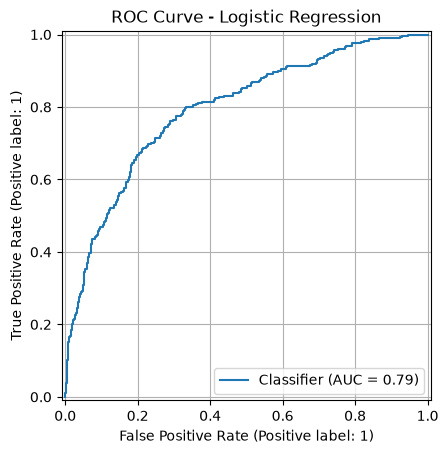


--- 5-FOLD CROSS-VALIDATION ҮР ДҮН ---
F1 Score (Дундаж): 0.3790 (Стандарт хазайлт: 0.0366)
ROC-AUC (Дундаж): 0.7907 (Стандарт хазайлт: 0.0141)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)


df=pd.read_csv('../data/features_df.csv')
y = df["is_churned"]
X = df.drop(columns=["is_churned", "customer_id"], errors="ignore")
X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)


pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]


print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, pred))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, pred))


auc_val = roc_auc_score(y_test, proba)
print(f"\nROC-AUC Score: {auc_val:.4f}")

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, proba)
plt.title("ROC Curve - Logistic Regression")
plt.grid(True)
plt.show()

cv_f1 = cross_val_score(model, X, y, cv=5, scoring="f1")
cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc")

print("\n--- 5-FOLD CROSS-VALIDATION ҮР ДҮН ---")
print(f"F1 Score (Дундаж): {cv_f1.mean():.4f} (Стандарт хазайлт: {cv_f1.std():.4f})")
print(f"ROC-AUC (Дундаж): {cv_auc.mean():.4f} (Стандарт хазайлт: {cv_auc.std():.4f})")